# Analysis

In [ ]:
!pip install torch numpy matplotlib seaborn pandas peft

## Analyzing EigCov Covariance Estimator

In [ ]:
import sys
from tqdm import tqdm
from itertools import product

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..") # Add src to path
import src.mhas as mhas
from src.vision.task_vectors import NonLinearTaskVector


MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
SPLIT = "train"
# DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
DATASETS = ["Cars"]
FT_METHODS = ["standard"]
THRESHOLDS = [0.9, 0.95, 0.99]
K_VALS = [8, 32, 64, 128, 256,  512, 1024]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
# dist_fn = lambda x, x_hat: (torch.linalg.norm(x - x_hat, ord="fro") / torch.linalg.norm(x, ord="fro")).item()
def dist_fn(A, B, k):
    """Grassmann chordal distance between top-k eigenspaces of A and B."""
    _, U_a = torch.linalg.eigh(A.double())
    _, U_b = torch.linalg.eigh(B.double())
    k = min(k, U_a.shape[1])
    U_a = U_a[:, -k:]
    U_b = U_b[:, -k:]
    sigmas = torch.linalg.svdvals(U_a.T @ U_b)
    val = k - (sigmas**2).sum()
    return torch.sqrt(val.clamp(min=0)).item()

def get_k_for_variance(C, threshold):
    """Get k that explains threshold fraction of variance."""
    eigvals = torch.linalg.eigvalsh(C)
    cumvar = eigvals.flip(0).cumsum(0) / eigvals.sum()
    return (cumvar < threshold).sum().item() + 1

rows = []
for ft_method, dataset in tqdm(product(FT_METHODS, DATASETS)):
    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/zeroshot.pt"
    if ft_method == "lora":
        finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/lora_finetuned.pt"
    else:
        finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/finetuned.pt"

    # Load covariance
    covs = np.load(f"{RESULTS_DIR}/covariances_strain_n100_b32_tsm_attnsplit_efull_ft{ft_method}/covariance_{dataset}.npz", allow_pickle=True)

    # Load task vector
    task_vector = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)
    task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

    # pbar = tqdm(, total=len(task_vector.vector))
    for i, (k, m) in enumerate(task_vector.vector.items()):
        kp = param_name_to_module_name(k)
        if len(m.shape) != 2 or kp not in covs.keys():
            continue
        # move to device
        m = m.to(DEVICE)
        c = torch.from_numpy(covs[kp]).to(m.dtype).to(DEVICE)
        c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=DEVICE)
        c_hat_ec = m.T @ m # EigenCov estimate
        c_hat_zero = torch.zeros_like(c, device=DEVICE)
        for kk in K_VALS:
            for method, c_hat in [("EigenCov", c_hat_ec), ("Identity", c_hat_ident), ("Zero", c_hat_zero)]:
                rows.append({
                    "dataset": dataset, "layer_name": k, "layer_idx": i,
                    "method": method, "error": dist_fn(c, c_hat, kk),
                    "k": kk, "ft_method": ft_method,
                })
        print(f"[{ft_method} | {dataset}] [{i:2d}/{len(task_vector.vector):2d}] {k:<{50}s} | M: {str(m.shape):>20s} | C: {str(c.shape):>20s}")


# Save
df = pd.DataFrame(rows)
df.to_csv(f"{RESULTS_DIR}/eigcov_estimation.csv", index=False)

0it [00:00, ?it/s]

[standard | Cars] [13/206] model.visual.transformer.resblocks.0.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[standard | Cars] [15/206] model.visual.transformer.resblocks.0.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[standard | Cars] [21/206] model.visual.transformer.resblocks.1.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[standard | Cars] [23/206] model.visual.transformer.resblocks.1.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[standard | Cars] [29/206] model.visual.transformer.resblocks.2.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[standard | Cars] [31/206] model.visual.transformer.resblocks.2.mlp.c_proj.weight | M: torch.Size([768, 3072]) | C: torch.Size([3072, 3072])
[standard | Cars] [37/206] model.visual.transformer.resblocks.3.mlp.c_fc.weight | M: torch.Size([3072, 768]) | C: torch.Size([768, 768])
[standard | Cars] [39/206] mo

1it [15:49, 949.35s/it]

[standard | Cars] [201/206] model.visual.transformer.resblocks.5.attn.o.weight | M: torch.Size([768, 768]) | C: torch.Size([768, 768])


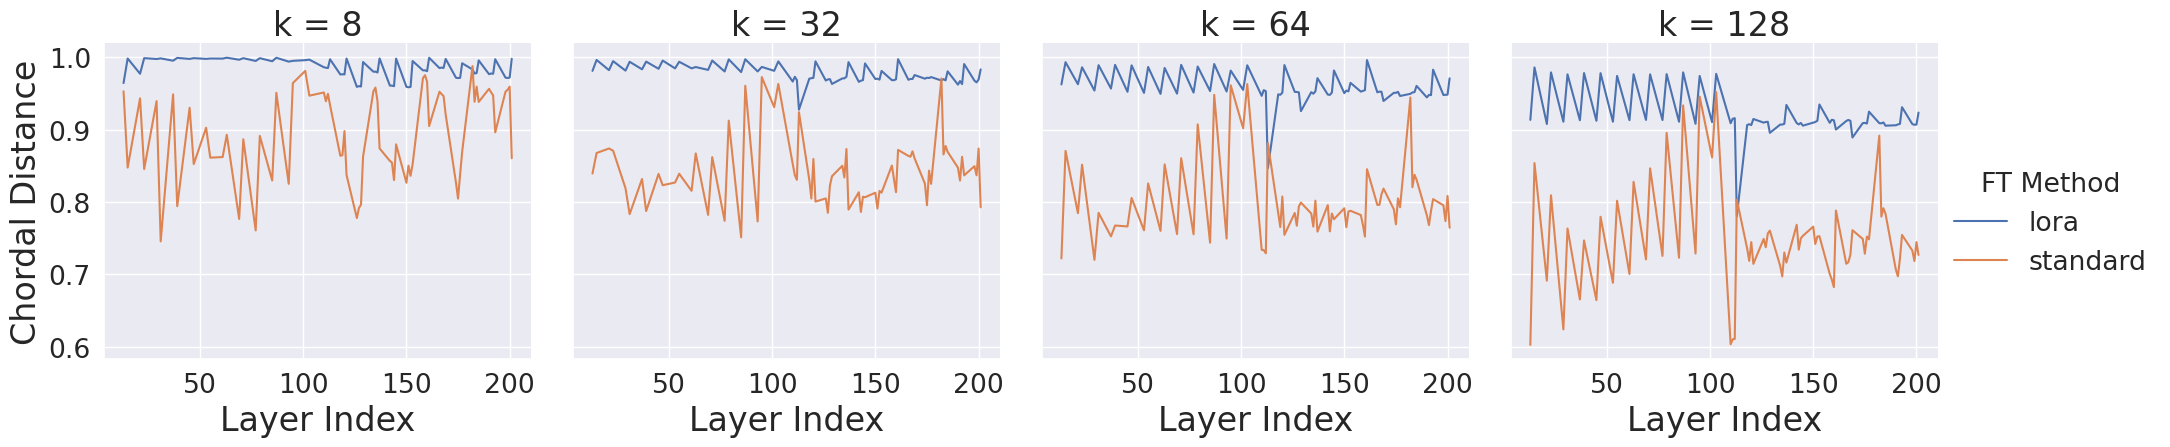

In [47]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

BASE_FONTSIZE = 24

sns.set_theme(rc={
    "font.size": BASE_FONTSIZE,
    "axes.titlesize": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE * 0.8,
    "ytick.labelsize": BASE_FONTSIZE * 0.8,
    "legend.fontsize": BASE_FONTSIZE * 0.8,
    "legend.title_fontsize": BASE_FONTSIZE * 0.8,
})

df = pd.read_csv(f"{RESULTS_DIR}/eigcov_estimation.csv")
df = df[df["method"] == "EigenCov"]
df = df[df["k"] <= 128]
df["error"] = df["error"] / np.sqrt(df["k"])

g = sns.relplot(
    data=df,
    x="layer_idx",
    y="error",
    hue="ft_method",
    col="k",
    kind="line",
    facet_kws={"sharey": True, "legend_out": True},  # <- goes here
    legend="brief",
)

g.set_axis_labels("Layer Index", "Chordal Distance")
g.set_titles(col_template="k = {col_name}")

# rename legend title without manual positioning
g.legend.set_title("FT Method")

g.figure.savefig(
    f"{RESULTS_DIR}/eigcov_estimation_line.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.2,   # small padding to avoid clipping
)

### Misc

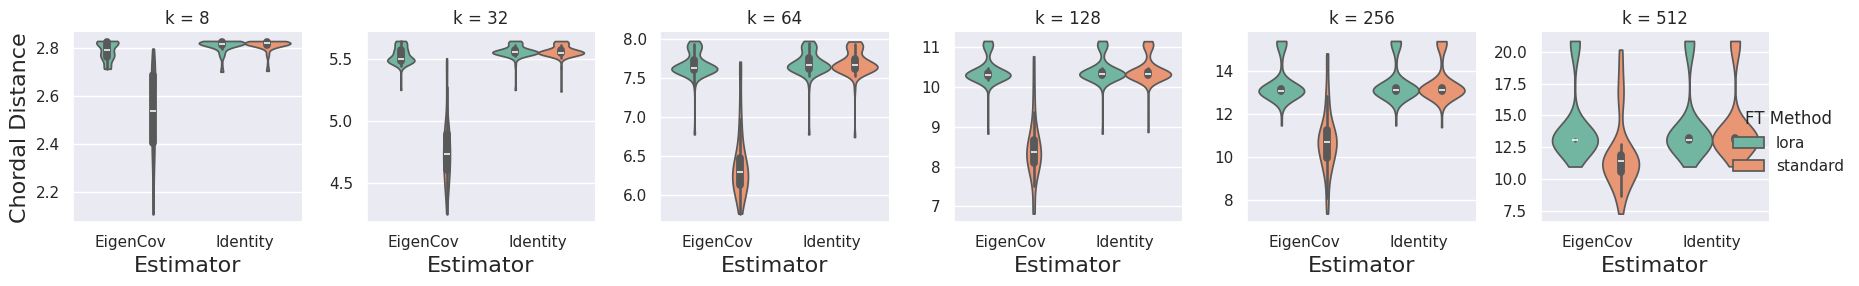

In [ ]:
# Load from csv
df = pd.read_csv(f"{RESULTS_DIR}/eigcov_estimation.csv")
df = df[df['method'] != 'Zero']
df = df[df['k'] != 1024]
BASE_FONTSIZE = 16
sns.set_theme()
g = sns.FacetGrid(data=df, col="k", sharey=False)
g.map_dataframe(sns.violinplot, x="method", y="error", hue="ft_method", palette="Set2", cut=0)
g.set_ylabels("Chordal Distance", fontsize=BASE_FONTSIZE)
g.set_xlabels("Estimator", fontsize=BASE_FONTSIZE)
g.add_legend(title="FT Method", bbox_to_anchor=(0.95, 0.5), loc="center left")
plt.savefig(f"{RESULTS_DIR}/eigcov_estimation_violin.pdf", dpi=300, bbox_inches="tight")


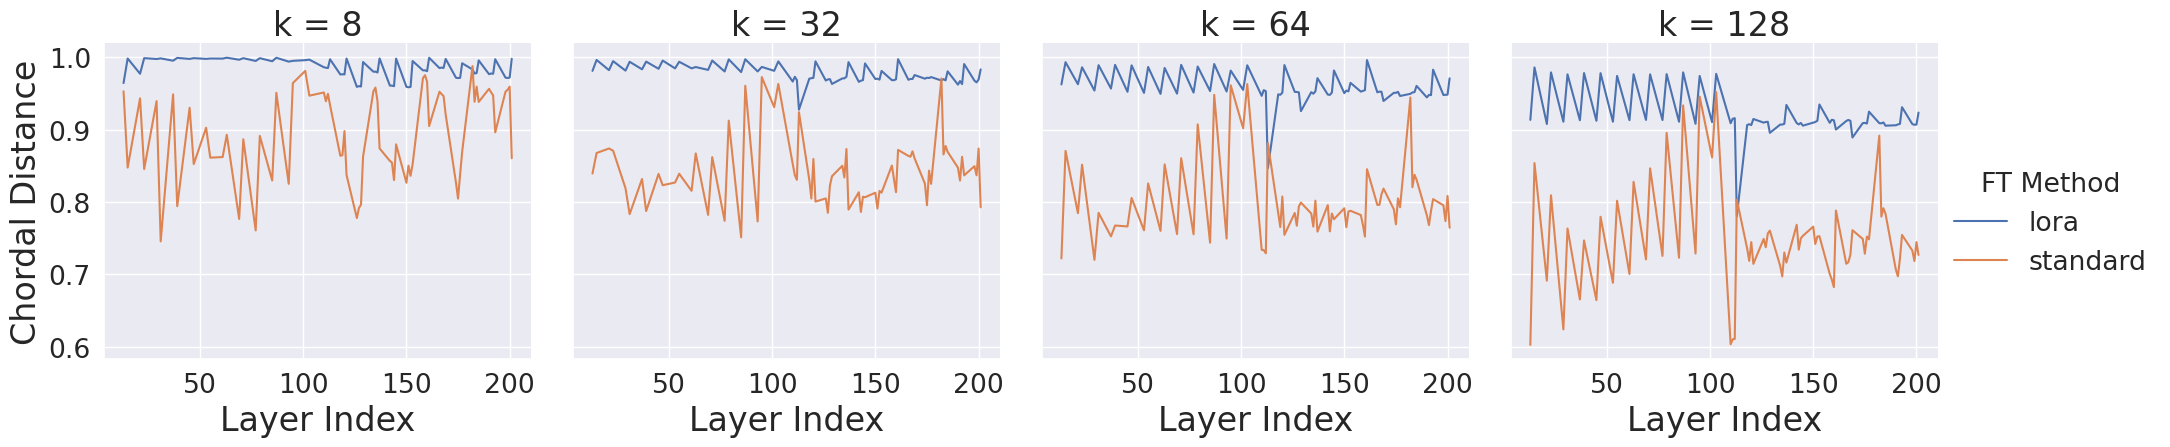

<Axes: xlabel='variance_thresh', ylabel='error'>

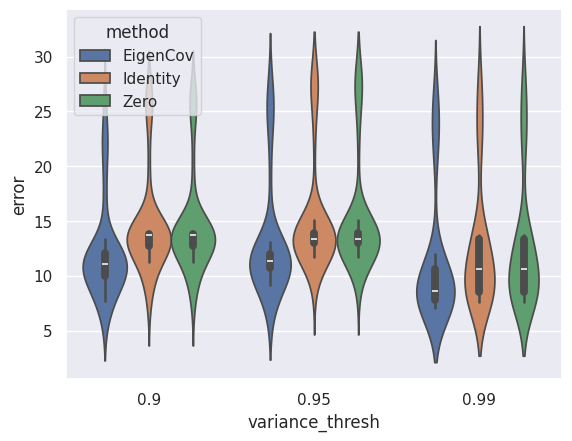

In [ ]:
import pandas as pd
df = pd.DataFrame(rows)
df = df[df['method'] != 'Zero']
sns.set_theme()
sns.violinplot(data=df, x="variance_thresh", y="error", hue="method")

In [ ]:
import os
import pickle
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from itertools import product
import torch

# Add src to path
sys.path.append("..")

import src.mhas as mhas
from src.vision.task_vectors import NonLinearTaskVector


MODEL_NAME = "ViT-B-16"
RESULTS_DIR = f"../results/{MODEL_NAME}"
CHECKPOINT_DIR = f"../checkpoints/{MODEL_NAME}"
SPLIT = "train"
# DATASETS = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "SVHN"]
DATASETS = ["Cars"]


param_name_to_module_name = lambda name: "image_encoder." + name.replace(".weight", "")
dist_fn = lambda x, x_hat: (torch.linalg.norm(x - x_hat, ord="fro") / torch.linalg.norm(x, ord="fro")).item()

rows = []


for dataset, ckpt_idx in tqdm(product(DATASETS, range(0, 2000, 500)), total=len(DATASETS) * len(range(0, 2000, 500)), desc="Datasets x Checkpoints"):
    pretrained_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/zeroshot.pt"
    finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/finetuned.pt"
    # finetuned_checkpoint = f"{CHECKPOINT_DIR}/{dataset}Val/checkpoint_{ckpt_idx}.pt"

    # Load covariance
    covs = np.load(f"{RESULTS_DIR}/covariance_{dataset}_{SPLIT}_b32_n10_attnsplit.npz", allow_pickle=True)
    # covs = np.load(f"{RESULTS_DIR}/covariance_{dataset}.npz", allow_pickle=True)
    # results/ViT-B-16/covariance_Cars_train_b32_n50_attnsplit.npz

    # Load task vector
    task_vector = NonLinearTaskVector(pretrained_checkpoint, finetuned_checkpoint)
    task_vector = task_vector.map(mhas.copy_from_pytorch_state_dict)

    for i, (k, m) in enumerate(task_vector.vector.items()):
        # print(param_name_to_module_name(k),  param_name_to_module_name(k) in covs.keys())
        # if not a 2D matrix, skip
        kp = param_name_to_module_name(k)
        if len(m.shape) != 2:
            # print("[skipping] not a 2D matrix", k)
            continue
        if kp not in covs.keys():
            # print("[skipping] not in covs", k)
            continue
        c = torch.from_numpy(covs[kp]).to(m.dtype).to(m.device)
        c_hat_ident = torch.eye(c.shape[0], c.shape[1], dtype=c.dtype, device=c.device)
        c_hat_ec = m.T @ m # EigenCov estimate
        print(f"{k} | M: {m.shape} | C: {c.shape}")
        rows.append(
            {"dataset": dataset, "layer_name": k, "layer_idx": i, "method": "EigenCov", "error": dist_fn(c, c_hat_ec), "ckpt_idx": ckpt_idx}
        )
        rows.append(
            {"dataset": dataset, "layer_name": k, "layer_idx": i, "method": "Identity", "error": dist_fn(c, c_hat_ident), "ckpt_idx": ckpt_idx}
        )
    break


    dataset                                         layer_name  layer_idx  \
0      Cars  model.visual.transformer.resblocks.0.mlp.c_fc....         13   
1      Cars  model.visual.transformer.resblocks.0.mlp.c_fc....         13   
2      Cars  model.visual.transformer.resblocks.0.mlp.c_pro...         15   
3      Cars  model.visual.transformer.resblocks.0.mlp.c_pro...         15   
4      Cars  model.visual.transformer.resblocks.1.mlp.c_fc....         21   
..      ...                                                ...        ...   
139    Cars  model.visual.transformer.resblocks.10.attn.k.w...        199   
140    Cars  model.visual.transformer.resblocks.10.attn.v.w...        200   
141    Cars  model.visual.transformer.resblocks.10.attn.v.w...        200   
142    Cars  model.visual.transformer.resblocks.10.attn.o.w...        201   
143    Cars  model.visual.transformer.resblocks.10.attn.o.w...        201   

       method      error  ckpt_idx  
0    EigenCov   1.000000         0  
1

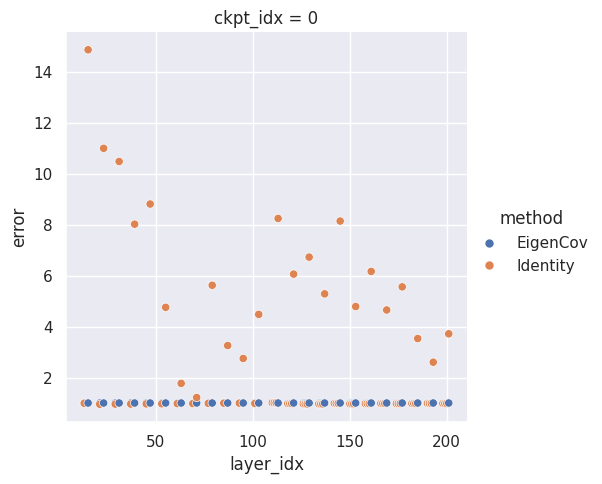

In [7]:
import pandas as pd
df = pd.DataFrame(rows)
print(df)


sns.set_theme()
sns.relplot(data=df, x="layer_idx", y="error", hue="method", row='ckpt_idx')

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(alphas, totals, "o-", linewidth=2, markersize=5)
ax.set_xlabel(r"$\alpha$", fontsize=14)
ax.set_ylabel(r"Total Interference $\mathcal{L}$", fontsize=14)
ax.set_title(f"Interference vs scaling coefficient ({model})")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{results_dir}/interference_vs_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

## Fig. 1: Decorrelation


$ρ(\|a[l-1]\|^2 \;, \|g[l]\|^2)$

/tmp/ipykernel_522165/3209624596.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


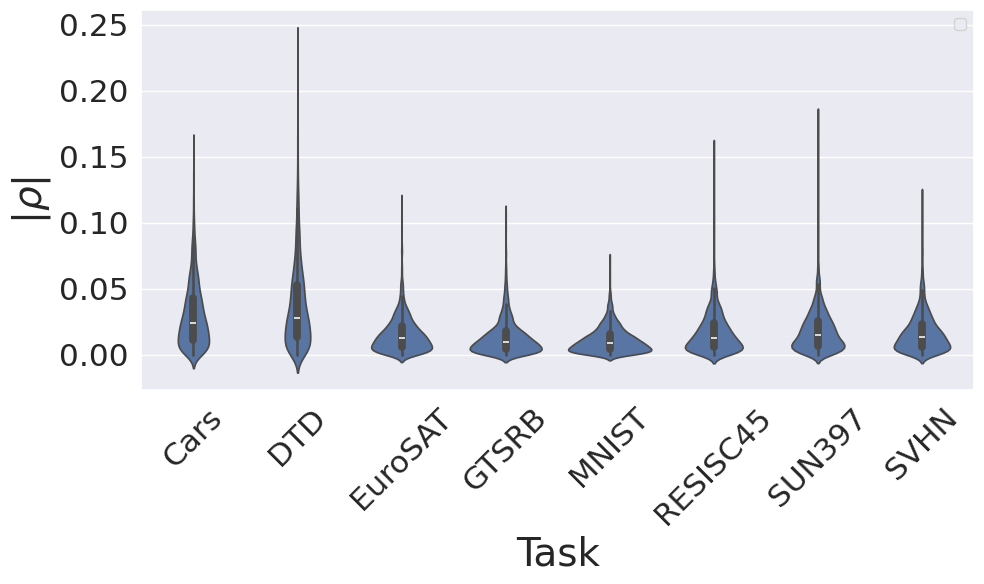


Summary Statistics (all points):
           mean    std    50%    max
task                                
Cars      0.030  0.024  0.024  0.157
DTD       0.037  0.032  0.028  0.235
EuroSAT   0.015  0.013  0.012  0.116
GTSRB     0.013  0.013  0.010  0.107
MNIST     0.011  0.010  0.009  0.072
RESISC45  0.017  0.015  0.013  0.156
SUN397    0.018  0.015  0.015  0.180
SVHN      0.017  0.015  0.013  0.119

Overall mean |ρ|: 0.020
% of all correlations < 0.1: 99.2%


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

sns.set_theme()
BASE_FONTSIZE=28

model = "ViT-B-16"
results_dir = f"../results/{model}"
tasks = ["Cars", "DTD", "EuroSAT", "GTSRB", "MNIST", "RESISC45", "SUN397", "SVHN"]
ignore = ["ln_", "ls_", "conv", "patch_dropout"]

corr = lambda x, y: np.corrcoef(x, y)[0, 1] if x.std() > 0 and y.std() > 0 else 0.0

rows = []
for task in tasks:
    path = f"{results_dir}/decorrelation_{task}.npz"
    if not os.path.exists(path):
        continue
    data = np.load(path)
    layers = sorted(k[5:] for k in data.files if k.startswith("g_sq/"))
    layers = [l for l in layers if not any(ig in l for ig in ignore)]

    for idx_l, l in enumerate(layers):
        g, aat = data[f"g_sq/{l}"], data[f"aat_samples/{l}"]
        N_samples, N_indices = aat.shape
        for idx_i in range(N_indices):
            rho = np.abs(corr(g, aat[:, idx_i]))
            rows.append({'task': task, 'layer': l, 'layer_idx': idx_l, 'entry_idx': idx_i, 'rho': rho})

df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x="task", y="rho", ax=ax)

ax.set_xlabel("Task", fontsize=BASE_FONTSIZE)
ax.set_ylabel(r"$|\rho|$", fontsize=BASE_FONTSIZE)
ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8, rotation=45)
ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
# ax.axhline(0.1, color='black', linestyle='--', alpha=0.5, label=r'$\rho=0.1$')
ax.legend()

plt.tight_layout()
plt.savefig(f"{results_dir}/decorrelation_violin.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\nSummary Statistics (all points):")
print(df.groupby('task')['rho'].describe()[['mean', 'std', '50%', 'max']].round(3).to_string())
print(f"\nOverall mean |ρ|: {df['rho'].mean():.3f}")
print(f"% of all correlations < 0.1: {(df['rho'] < 0.1).mean() * 100:.1f}%")

## Fig.2 : Accuracy vs. Number of Samples used for Covariance Estimation

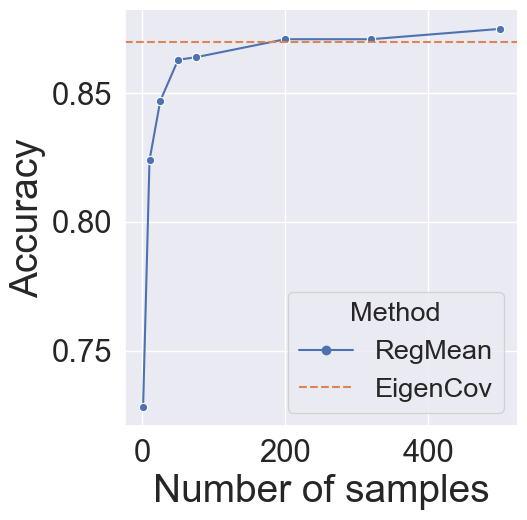

In [53]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt

BASE_FONTSIZE = 28

shared_params = {
    "model": "ViT-B-16",
    "split": "train",
    "cov_type": "sm",
    "estimator": "full",
    "finetune_mode": "full",
    "method": "RegMean",
}

rows = [
    {**shared_params, "n": 1, "acc_abs": 0.728, "acc_rel": 0.772},
    {**shared_params, "n": 10, "acc_abs": 0.824, "acc_rel": 0.871},
    {**shared_params, "n": 25, "acc_abs": 0.847, "acc_rel": 0.895},
    {**shared_params, "n": 50, "acc_abs": 0.863, "acc_rel": 0.911},
    {**shared_params, "n": 75, "acc_abs": 0.864, "acc_rel": 0.913},
    {**shared_params, "n": 320, "acc_abs": 0.871, "acc_rel": 0.918},
    {**shared_params, "n": 200, "acc_abs": 0.871, "acc_rel": 0.919},
    {**shared_params, "n": 500, "acc_abs": 0.875, "acc_rel": 0.923},
]

df = pd.DataFrame(rows)

sns.set_theme()
g = sns.relplot(data=df, x="n", y="acc_abs", hue="method", style="method", kind="line", markers=True)
g.set_ylabels("Accuracy", fontsize=BASE_FONTSIZE)
g.set_xlabels("Number of samples", fontsize=BASE_FONTSIZE)
g.ax.tick_params(axis='x', labelsize=BASE_FONTSIZE * 0.8)
g.ax.tick_params(axis='y', labelsize=BASE_FONTSIZE * 0.8)
g.ax.axhline(y=0.87, color=sns.color_palette()[1], linestyle="--", label="EigenCov")
handles, labels = g.ax.get_legend_handles_labels()
g.ax.legend(handles, labels, title="Method", fontsize=BASE_FONTSIZE * 0.7, title_fontsize=BASE_FONTSIZE * 0.7)
g._legend.remove()

# Save as pdf
results_dir = f"../results"
model = "ViT-B-16"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(f"{results_dir}/{model.lower()}_acc_vs_n.pdf", dpi=300, bbox_inches="tight")

